In [1]:
# Import libraries

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# don't truncate columns in pandas
pd.set_option('display.max_colwidth', None)
pd.options.display.max_rows = 300

In [2]:
# Get the CSV from link - Process entire file in chunks
path = '../csv_files/gedi_oldgrowth_joined_full_data.csv'

chunk_size = 100000  # Process 100k rows at a time
chunks = []

print("Reading file in chunks...")
for i, chunk in enumerate(pd.read_csv(path, chunksize=chunk_size)):
    # # Apply transformations to each chunk using defined functions
    # chunk['date'] = chunk['source_url'].apply(get_date)
    # chunk['land_class'] = chunk['RASTERVALU'].apply(label_raster_val)
    
    # # Remove rows marked as deforestation_2007
    # chunk = chunk[chunk['land_class'] != 'deforestation_2007']
    
    chunks.append(chunk)
    print(f"  Processed chunk {i+1} ({len(chunk)} rows)")

# Combine all chunks
df = pd.concat(chunks, ignore_index=True)
print(f"\nTotal rows loaded: {len(df):,}")
print(df.iloc[0])

Reading file in chunks...
  Processed chunk 1 (100000 rows)
  Processed chunk 2 (100000 rows)
  Processed chunk 3 (100000 rows)
  Processed chunk 4 (100000 rows)
  Processed chunk 5 (100000 rows)
  Processed chunk 6 (100000 rows)
  Processed chunk 7 (100000 rows)
  Processed chunk 8 (100000 rows)
  Processed chunk 9 (100000 rows)
  Processed chunk 10 (100000 rows)
  Processed chunk 11 (100000 rows)
  Processed chunk 12 (100000 rows)
  Processed chunk 13 (100000 rows)
  Processed chunk 14 (100000 rows)
  Processed chunk 15 (100000 rows)
  Processed chunk 16 (100000 rows)
  Processed chunk 17 (100000 rows)
  Processed chunk 18 (100000 rows)
  Processed chunk 19 (100000 rows)
  Processed chunk 20 (100000 rows)
  Processed chunk 21 (100000 rows)
  Processed chunk 22 (100000 rows)
  Processed chunk 23 (100000 rows)
  Processed chunk 24 (100000 rows)
  Processed chunk 25 (100000 rows)
  Processed chunk 26 (100000 rows)
  Processed chunk 27 (100000 rows)
  Processed chunk 28 (100000 rows)
  P

In [12]:
# confirm there is only one index (0 - indicating old growth)
unique_indexes = df['index_right'].unique()
unique_shape_leng = df['Shape_Leng'].unique()
unique_shape_area = df['Shape_Area'].unique()

print(f"Number of different indexes/land cover types - should be 1 (old growth only): {len(unique_indexes)}")
print(f"Number of different shape lengths: {len(unique_shape_leng)}")
print(f"Number of different shape areas: {len(unique_shape_area)}")


Number of different indexes/land cover types - should be 1 (old growth only): 1
Number of different shape lengths: 1
Number of different shape areas: 1


In [13]:
# Remove negative RH values
print("Total rows before removing negative RH values: ", len(df))

df = df[
    (df['rh25'] >= 0) & 
    (df['rh50'] >= 0) & 
    (df['rh75'] >= 0) & 
    (df['rh95'] >= 0)
]

print("Total rows after removing negative RH values: ", len(df))

Total rows before removing negative RH values:  20352204
Total rows after removing negative RH values:  20352204


In [17]:
# Basic statistics for old growth forest
metrics = ['rh25', 'rh50', 'rh75', 'rh95']

print(df[metrics].describe())

print("\n=== MEAN VALUES ===")
for metric in metrics:
    print(f"{metric.upper()}: {df[metric].mean():.2f} m")

               rh25          rh50          rh75          rh95
count  2.035220e+07  2.035220e+07  2.035220e+07  2.035220e+07
mean   8.558858e+00  1.482383e+01  2.031915e+01  2.613960e+01
std    5.162172e+00  7.208220e+00  9.385485e+00  1.136220e+01
min    0.000000e+00  7.800000e-01  1.610000e+00  4.000000e+00
25%    4.560000e+00  9.770000e+00  1.437000e+01  1.939000e+01
50%    8.200000e+00  1.429000e+01  1.950000e+01  2.531000e+01
75%    1.202000e+01  1.899000e+01  2.486000e+01  3.130000e+01
max    1.389900e+02  1.677500e+02  1.847400e+02  2.025500e+02

=== MEAN VALUES ===
RH25: 8.56 m
RH50: 14.82 m
RH75: 20.32 m
RH95: 26.14 m


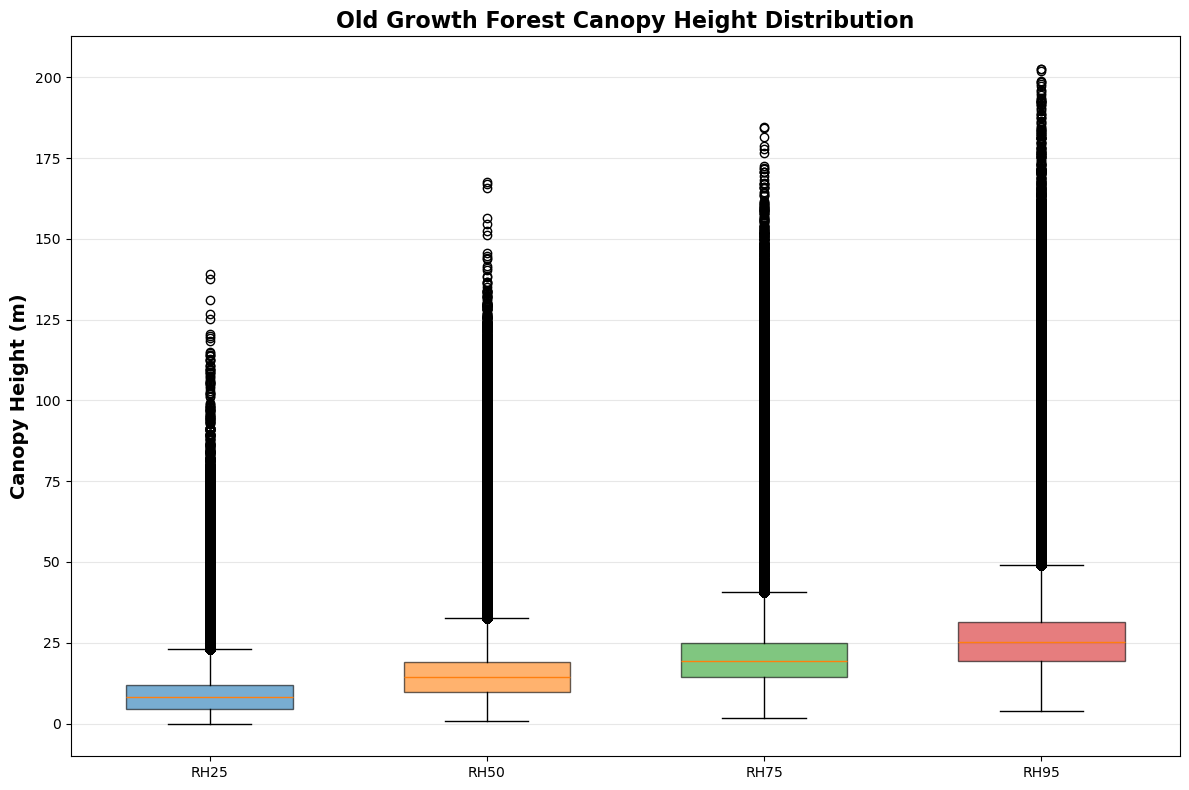

In [20]:
# Boxplots for old growth forest RH values
metrics = ['rh25', 'rh50', 'rh75', 'rh95']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(12, 8))

data_by_metric = [df[metric] for metric in metrics]

bp = ax.boxplot(data_by_metric, tick_labels=['RH25', 'RH50', 'RH75', 'RH95'], 
                patch_artist=True, widths=0.6)

for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.6)

ax.set_ylabel('Canopy Height (m)', fontsize=14, fontweight='bold')
ax.set_title('Old Growth Forest Canopy Height Distribution', fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

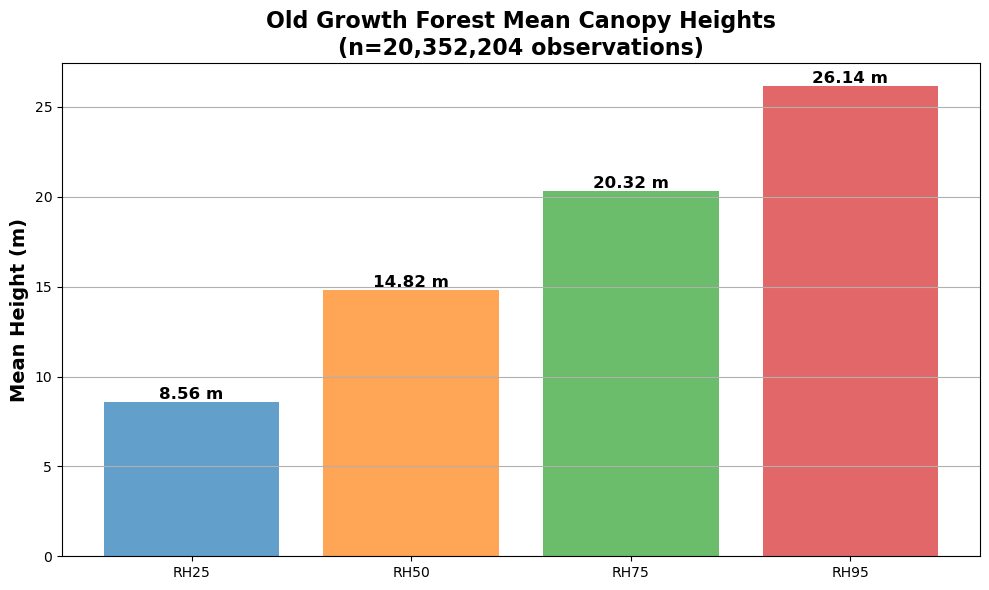

In [21]:
metrics = ['rh25', 'rh50', 'rh75', 'rh95']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

mean_heights = [df[metric].mean() for metric in metrics]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(['RH25', 'RH50', 'RH75', 'RH95'], mean_heights, color=colors, alpha=0.7)

ax.set_ylabel('Mean Height (m)', fontsize=14, fontweight='bold')
ax.set_title(f'Old Growth Forest Mean Canopy Heights\n(n={len(df):,} observations)', 
             fontsize=16, fontweight='bold')
ax.grid(axis='y')

# Label bars with values
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f m', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()